In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv("uber.csv")

In [8]:
df.head()        
df.info()       
df.describe()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [9]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

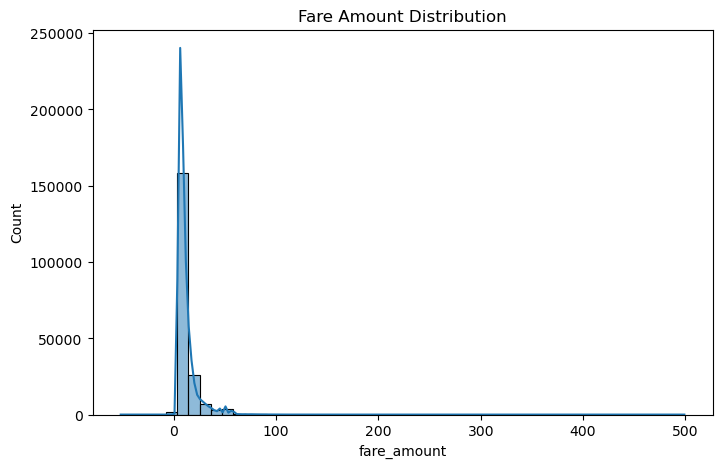

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['fare_amount'], bins=50, kde=True)
plt.title("Fare Amount Distribution")
plt.show()

In [12]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

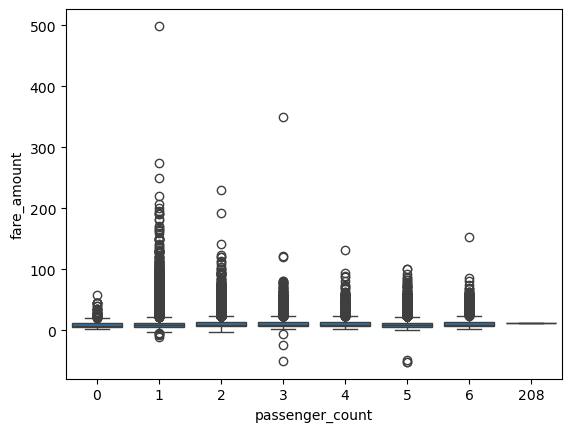

In [14]:
sns.boxplot(x='passenger_count', y='fare_amount', data=df)
plt.show()

In [15]:
df[df['fare_amount'] < 0]
df[df['fare_amount'] > 100]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2053,31333682,2014-11-01 08:42:39.0000002,113.66,2014-11-01 08:42:39 UTC,-73.951227,40.778753,-73.949938,40.778149,1
4292,33491441,2014-10-24 20:20:00.000000181,350.00,2014-10-24 20:20:00 UTC,0.000000,0.000000,0.000000,0.000000,3
5968,28138818,2011-05-06 00:40:00.000000224,105.00,2011-05-06 00:40:00 UTC,-73.752265,40.923303,-73.752270,40.923303,1
6613,28579349,2013-05-03 10:05:00.000000192,137.00,2013-05-03 10:05:00 UTC,0.000000,0.000000,0.000000,0.000000,1
9060,33046347,2011-06-13 15:46:00.00000036,126.10,2011-06-13 15:46:00 UTC,-73.788657,40.640643,-74.001350,41.048048,1
...,...,...,...,...,...,...,...,...,...
190767,19562599,2012-09-03 00:21:00.00000051,120.30,2012-09-03 00:21:00 UTC,-73.788095,40.642330,-73.976730,40.931132,3
194454,34209729,2013-11-22 13:07:00.000000103,130.25,2013-11-22 13:07:00 UTC,-73.982272,40.763447,-74.177182,40.695032,1
196616,53659256,2014-02-02 04:43:45.0000003,109.00,2014-02-02 04:43:45 UTC,-73.984697,40.749896,-74.045293,40.973143,2
196647,13085828,2010-08-19 16:52:45.0000003,200.00,2010-08-19 16:52:45 UTC,-73.952994,40.736298,-73.952994,40.736298,1


In [16]:
df['passenger_count'].value_counts()

passenger_count
1      138425
2       29428
5       14009
3        8881
4        4276
6        4271
0         709
208         1
Name: count, dtype: int64

In [17]:
df[['pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude']].describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
count,200000.000000,200000.000000,199999.000000,199999.000000
mean,-72.527638,39.935885,-72.525292,39.923890
std,11.437787,7.720539,13.117408,6.794829
min,-1340.648410,-74.015515,-3356.666300,-881.985513
25%,-73.992065,40.734796,-73.991407,40.733823
50%,-73.981823,40.752592,-73.980093,40.753042
75%,-73.967154,40.767158,-73.963658,40.768001
max,57.418457,1644.421482,1153.572603,872.697628


In [18]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month

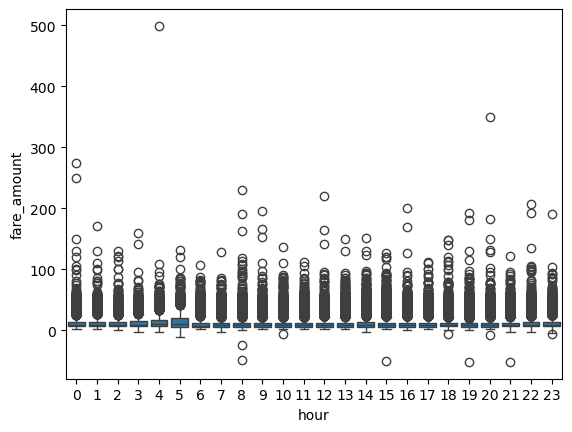

In [19]:
sns.boxplot(x='hour', y='fare_amount', data=df)
plt.show()

In [20]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
hour                 0
day                  0
month                0
dtype: int64

In [21]:
(df.isnull().sum() / len(df)) * 100

Unnamed: 0           0.0000
key                  0.0000
fare_amount          0.0000
pickup_datetime      0.0000
pickup_longitude     0.0000
pickup_latitude      0.0000
dropoff_longitude    0.0005
dropoff_latitude     0.0005
passenger_count      0.0000
hour                 0.0000
day                  0.0000
month                0.0000
dtype: float64

In [22]:
df = df.dropna()

In [23]:
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())

In [24]:
df.fillna({'passenger_count': df['passenger_count'].median()}, inplace=True)

In [25]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
hour                 0
day                  0
month                0
dtype: int64

In [26]:
df = df.dropna(subset=['pickup_datetime'])

In [27]:
import numpy as np

def haversine(lon1, lat1, lon2, lat2):
    R = 6371  # Earth radius in km

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['distance_km'] = haversine(
    df['pickup_longitude'], df['pickup_latitude'],
    df['dropoff_longitude'], df['dropoff_latitude']
)

In [28]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [29]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['weekday'] = df['pickup_datetime'].dt.weekday

In [30]:
def time_of_day(hour):
    if 5 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 21:
        return 'evening'
    else:
        return 'night'

df['time_of_day'] = df['hour'].apply(time_of_day)

In [31]:
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [37]:
def distance_category(d):
    if d < 2:
        return 'short'
    elif d < 10:
        return 'medium'
    else:
        return 'long'

df['distance_category'] = df['distance_km'].apply(distance_category)

In [34]:
df['is_shared_ride'] = df['passenger_count'].apply(lambda x: 1 if x > 1 else 0)

In [33]:
df = df[df['distance_km'] > 0]
df = df[df['distance_km'] < 100]

In [35]:
df['fare_per_km'] = df['fare_amount'] / df['distance_km']

In [38]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,      # 20% test data
    random_state=42     # reproducibility
)

In [40]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (155116, 18)
X_test: (38780, 18)
y_train: (155116,)
y_test: (38780,)


In [41]:
X = df.drop('fare_amount', axis=1)

In [42]:
df = df.drop('pickup_datetime', axis=1)

In [43]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

In [44]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

In [45]:
print(X.select_dtypes(include='object').columns)

Index(['key', 'time_of_day', 'distance_category'], dtype='object')


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
# No string columns
print(X.select_dtypes(include='object').columns)

# Should return empty

Index(['key', 'time_of_day', 'distance_category'], dtype='object')


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
df = df.drop(['pickup_datetime', 'key'], axis=1, errors='ignore')

In [50]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

In [51]:
print(X.select_dtypes(include='object').columns)

Index(['time_of_day', 'distance_category'], dtype='object')


In [52]:
X = pd.get_dummies(X, drop_first=True)

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
print(X_train.head())

        Unnamed: 0  pickup_longitude  pickup_latitude  dropoff_longitude  \
69293     27858740        -73.984847        40.739614         -74.008523   
187349    35739410        -74.005418        40.740622         -73.971772   
103652    12327421        -73.980055        40.758635         -73.941400   
52443     54278200        -73.991108        40.699542         -74.008735   
146143    18701253        -73.993858        40.761864         -73.972061   

        dropoff_latitude  passenger_count  hour  day  month  distance_km  \
69293          40.745576                2    15    9      5     2.101911   
187349         40.747110                5     0   12      5     2.924880   
103652         40.751123                1     8   23      3     3.361395   
52443          40.718885                1    18   26      4     2.614119   
146143         40.782951                1     9   23      6     2.977818   

        weekday  is_weekend  is_shared_ride  fare_per_km  time_of_day_evening  \
69293

In [56]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

In [57]:
corr_matrix = df_numeric.corr()

In [58]:
corr_target = corr_matrix['fare_amount'].sort_values(ascending=False)
print(corr_target)

fare_amount          1.000000
distance_km          0.840579
fare_per_km          0.123294
is_shared_ride       0.019009
passenger_count      0.011909
pickup_longitude     0.011752
dropoff_longitude    0.010269
Unnamed: 0           0.000704
is_weekend          -0.000024
pickup_latitude     -0.008367
dropoff_latitude    -0.008369
Name: fare_amount, dtype: float64


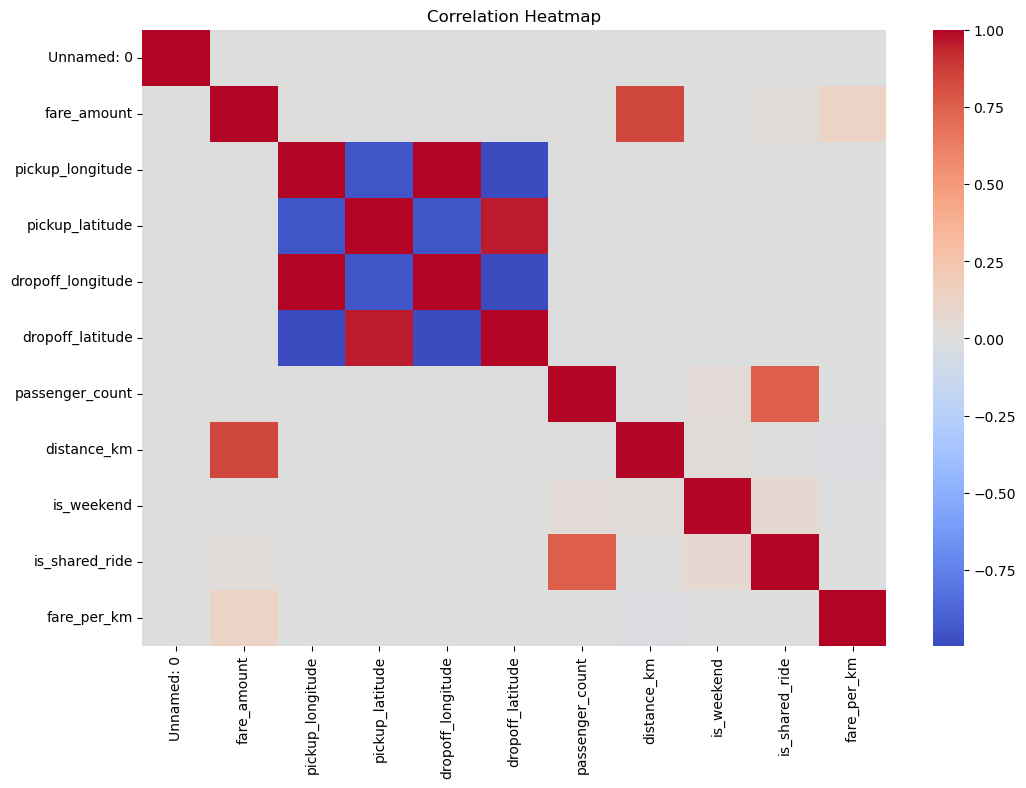

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

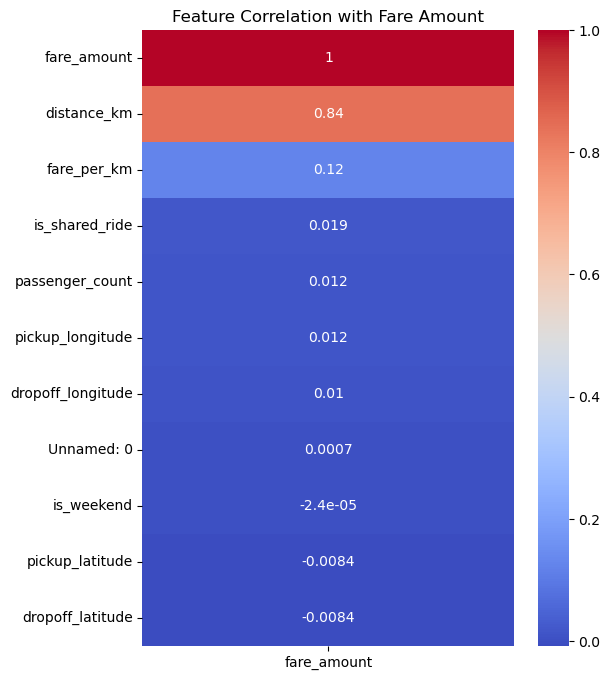

In [60]:
plt.figure(figsize=(6,8))
sns.heatmap(corr_target.to_frame(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Fare Amount")
plt.show()

In [61]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results:
MAE: 2.410384927508928
RMSE: 4.973267680205513
R2 Score: 0.7366007284718057


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [67]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)


Random Forest Results:
MAE: 0.06428171480144394
RMSE: 0.9471781523159202
R2 Score: 0.990445801872979


In [69]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

distance_km                 0.797452
fare_per_km                 0.184741
dropoff_longitude           0.004402
pickup_longitude            0.003763
dropoff_latitude            0.002730
pickup_latitude             0.002278
weekday                     0.000952
hour                        0.000608
day                         0.000593
is_weekend                  0.000568
Unnamed: 0                  0.000503
month                       0.000459
is_shared_ride              0.000390
passenger_count             0.000226
time_of_day_evening         0.000152
time_of_day_morning         0.000095
time_of_day_night           0.000070
distance_category_medium    0.000016
distance_category_short     0.000004
dtype: float64


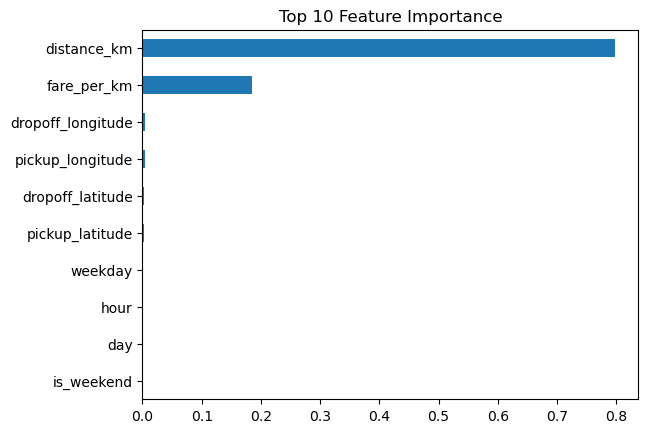

In [70]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [71]:
new_ride = {
    'pickup_longitude': 77.5946,
    'pickup_latitude': 12.9716,
    'dropoff_longitude': 77.6850,
    'dropoff_latitude': 12.9352,
    'passenger_count': 2,
    'distance_km': 8.5,
    'hour': 18,
    'day': 15,
    'month': 6,
    'weekday': 2,
    'is_weekend': 0,
    'is_shared_ride': 1
}

In [72]:
import pandas as pd

new_df = pd.DataFrame([new_ride])

In [73]:
new_df = new_df.reindex(columns=X.columns, fill_value=0)

In [74]:
predicted_fare = rf_model.predict(new_df)

print("Predicted Fare: ₹", predicted_fare[0])

Predicted Fare: ₹ 2.176


In [75]:
new_scaled = scaler.transform(new_df)
predicted_fare_lr = lr_model.predict(new_scaled)

print("Predicted Fare (LR): ₹", predicted_fare_lr[0])

Predicted Fare (LR): ₹ 19.539889350942005
